# Step 1: Import Required Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import imblearn
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline

# Step 2: Load the Dataset.

In [31]:
df = pd.read_csv(r"C:\Users\Ramla\OneDrive\Documents\Diabetes.csv")
print("Shape:", df.shape)
df.head()

Shape: (767, 11)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,RiskLevel,BMICategory
0,1,85,66,29,0,26.6,0.351,31,0,Low,Overweight
1,8,183,64,0,0,23.3,0.672,32,1,High,Normal
2,1,89,66,23,94,28.1,0.167,21,0,Low,Overweight
3,0,137,40,35,168,43.1,2.288,33,1,Medium,Obese
4,5,116,74,0,0,25.6,0.201,30,0,Medium,Overweight


# Step 3: Cleaning the Dataset

In [32]:
# Identify invalid zeros
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_cols:
    print(f"{col} has {df[df[col] == 0].shape[0]} zero entries.")

# Replace 0 with NaN and fill with median
df[invalid_cols] = df[invalid_cols].replace(0, np.nan)
df[invalid_cols] = df[invalid_cols].fillna(df[invalid_cols].median())

# Check for any remaining missing values
df.isnull().sum()

Glucose has 5 zero entries.
BloodPressure has 35 zero entries.
SkinThickness has 227 zero entries.
Insulin has 373 zero entries.
BMI has 11 zero entries.


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
RiskLevel                   0
BMICategory                 0
dtype: int64

# Step 4: Visualizing Feature Distributions.

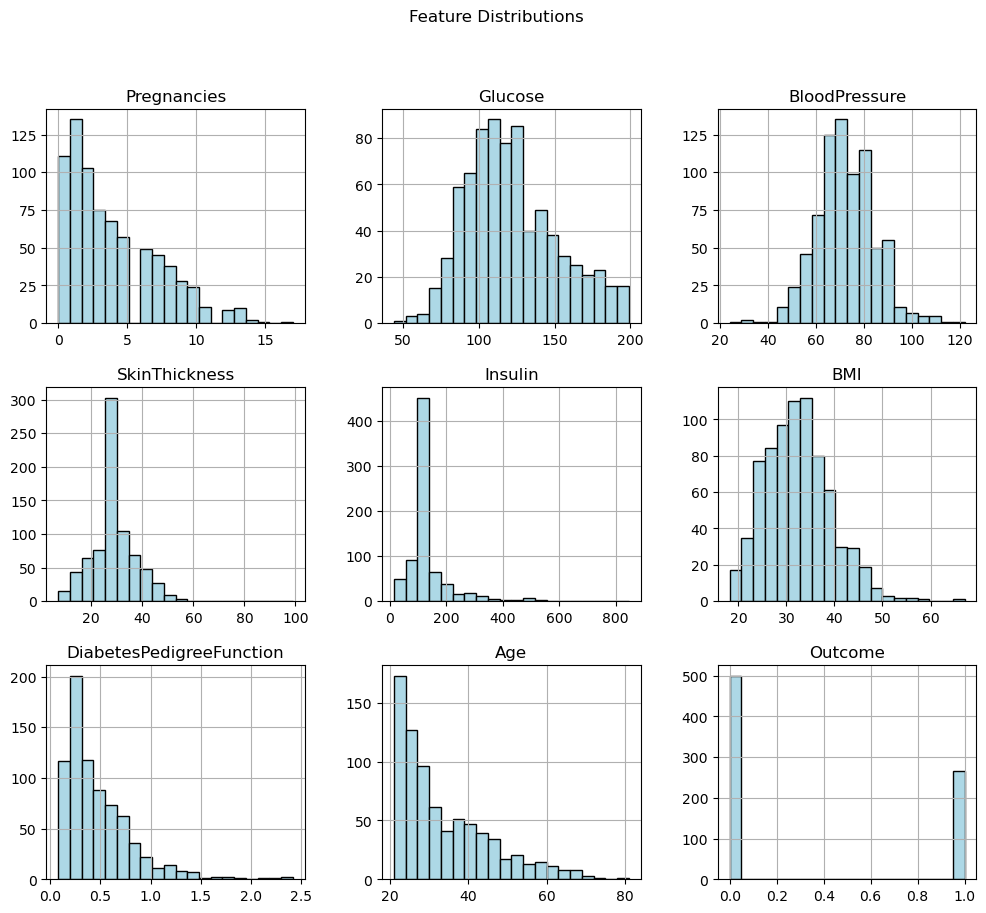

In [33]:
# Plot histograms for all features
df.hist(figsize=(12,10), bins=20, color='lightblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.show()

The histogram shows that each feature is distributed.
Glucose → Skewed right; most patients have lower glucose, but a few have very high

Insulin → Extremely skewed, many zeros or low values

Age → Most patients are younger, but there are older ones too

It helps decide whether scaling, transformation, or balancing is needed.

It also helps us to identify outliers and skewness visually.

# Step5: Data Preprocessing – Converting Categorical Columns to String

In [34]:
df['Outcome'] = df['Outcome'].astype(int)
df['RiskLevel'] = df['RiskLevel'].astype(str)
df['BMICategory'] = df['BMICategory'].astype(str)

# Step 6: Exploratory Data Analysis – Categorical Feature Relationships

In [39]:
# Create a copy for visualization
df_plot = df.copy()

# Map numeric Outcome to human-readable labels
df_plot['Outcome'] = df_plot['Outcome'].map({
    0: 'Not Diabetic',
    1: 'Diabetic'
})

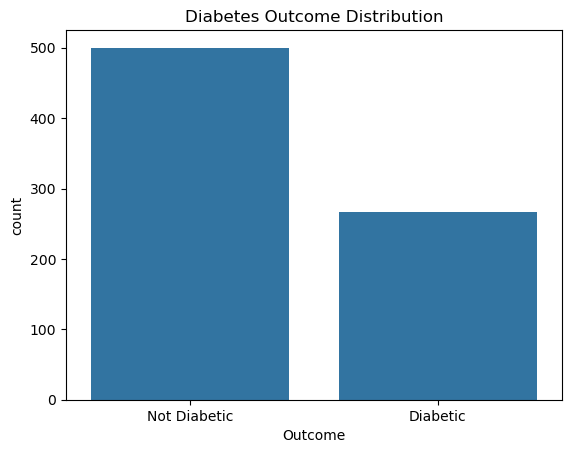

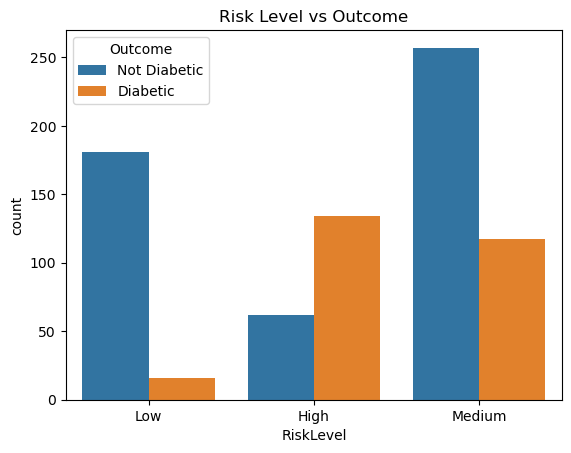

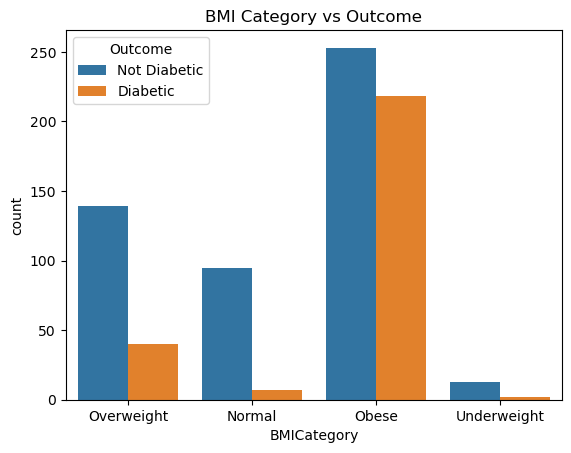

In [40]:
# Count Plot 1 – Diabetes Outcome Distribution
sns.countplot(x='Outcome' , data=df_plot)
plt.title("Diabetes Outcome Distribution")
plt.show()

# Count Plot 2 – Risk Level vs Outcome
sns.countplot(x='RiskLevel', hue='Outcome', data=df_plot)
plt.title('Risk Level vs Outcome')
plt.show()

# Count Plot 3 – BMI Category vs Outcome
sns.countplot(x='BMICategory', hue='Outcome', data=df_plot)
plt.title('BMI Category vs Outcome')
plt.show()

Outcome Distribution: Shows how many are diabetic (1) vs not diabetic (0).
More non-diabetic (0) patients than diabetic (1)
This shows class imbalance, which is later handled using SMOTE.

RiskLevel vs Outcome: Tells us how many people at each risk level are diabetic.
As risk level increases, number of diabetic patients increases
High risk → mostly diabetic
Low risk → mostly non-diabetic
This confirms that RiskLevel is a meaningful predictor.

BMICategory vs Outcome: Shows correlation between BMI category and diabetes.
Overweight/Obese people → more likely to be diabetic
Underweight/Normal BMI → fewer cases of diabetes
So there is a Strong connection between BMI and diabetes status.

These plots help us to understand relationships between variables and diabetes.

# Step 7: Label Encoding of Categorical Columns

In [41]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'RiskLevel',
       'BMICategory'],
      dtype='str')


In [44]:
# Initialize separate encoders
le_risk = LabelEncoder()
le_bmi = LabelEncoder()

# Fit and transform each categorical column
df['RiskLevel'] = le_risk.fit_transform(df['RiskLevel'])
df['BMICategory'] = le_bmi.fit_transform(df['BMICategory'])

# Optional: check first few rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,RiskLevel,BMICategory
0,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1,2
1,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,0,0
2,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1,2
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,2,1
4,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0,2,2


# Step 8: Exploratory Data Analysis – Correlation Matrix

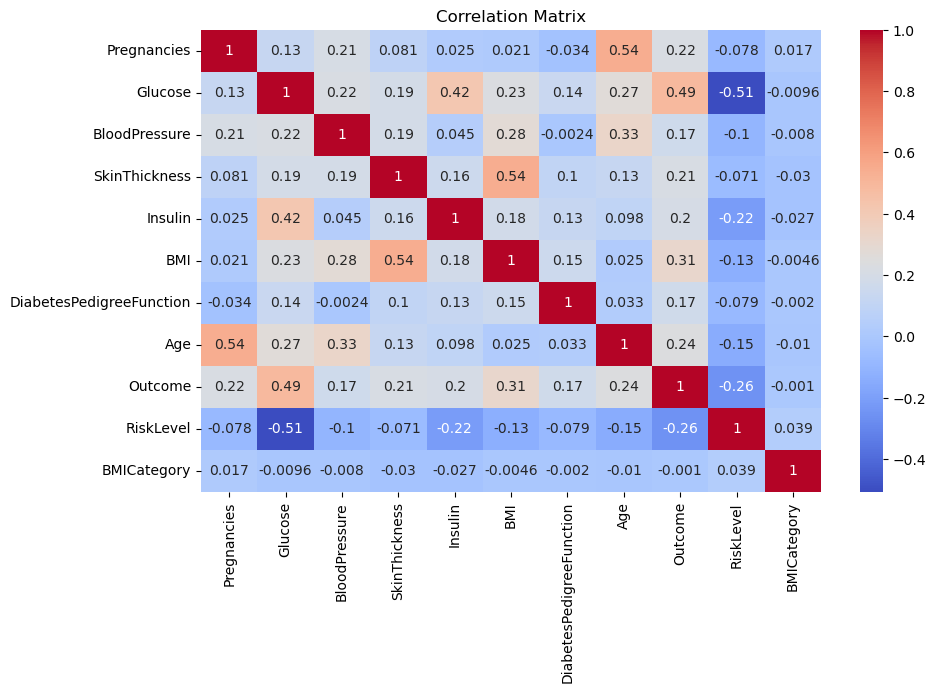

In [45]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

It shows the correlation values between each feature and diabetes outcome

Value ranges from -1 (negative) to +1 (positive)

Glucose has strongest positive correlation with diabetes

BMI, Age, Pregnancies → moderate positive correlation

BloodPressure → weak or no correlation

Useful for feature selection coz it shows which features are most predictive.

# Step 9: Exploratory Data Analysis – Boxplots of Key Features by Outcome

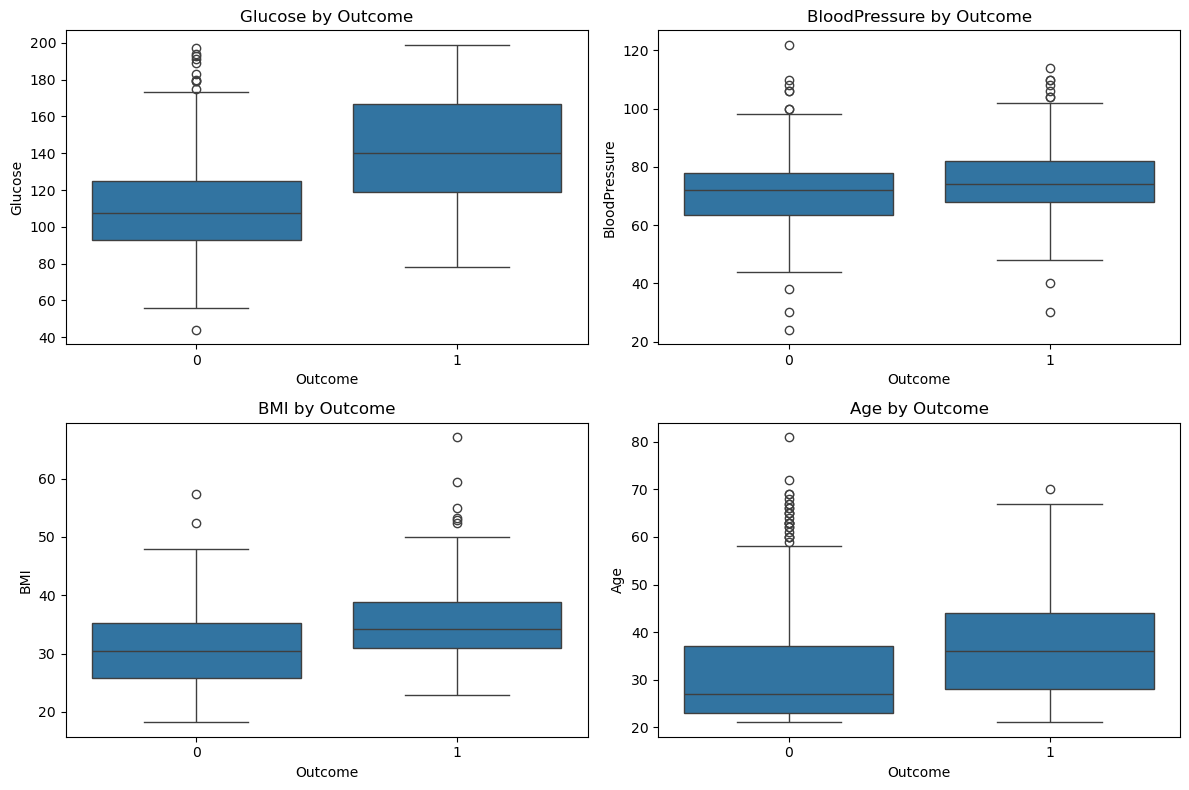

In [46]:
features = ['Glucose', 'BloodPressure', 'BMI', 'Age']
plt.figure(figsize=(12,8))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'{col} by Outcome')
plt.tight_layout()
plt.show()

It show the Median, spread, and outliers for features like Glucose, Age, BMI across diabetic vs non-diabetic
Glucose: Diabetics have much higher glucose levels
BMI: Diabetics tend to have higher BMI
Age: Diabetics are slightly older
BloodPressure: Difference is small

This Confirms that features like Glucose and BMI are top predictors.

# Step 10: Computing Skewness and Kurtosis of Feature

In [47]:
df.drop('Outcome', axis=1).apply([pd.Series.skew, pd.Series.kurt]).T

,skew,kurt
Pregnancies,0.903976,0.161293
Glucose,0.538571,-0.254341
BloodPressure,0.141668,1.092894
SkinThickness,0.840035,5.432628
Insulin,3.377341,16.205986
BMI,0.599523,0.915926
DiabetesPedigreeFunction,1.921190,5.593374
Age,1.135165,0.660872
RiskLevel,-0.455786,-1.403507
BMICategory,0.275469,0.255823


# Step 11: Split Data into Features (X) and Target (y)

In this step, we separate the dataset into input features (`X`) by dropping the target column `'Outcome'`, and the target variable (`y`) which contains the `'Outcome'` values.  
This prepares the data for model training and evaluation.

In [48]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

 # Step 12: Split Dataset into Training and Testing Sets

We split the features (`X`) and target (`y`) into training and testing sets using an 80-20 split.  
- `test_size=0.2` means 20% of data is reserved for testing.  
- `random_state=42` ensures reproducibility.  
- `stratify=y` maintains the target variable distribution in both sets.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 13: Apply SMOTE to Balance the Training Data

We use SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance by generating synthetic samples for the minority class in the training set.

- `smote.fit_resample()` creates a balanced training set.
- We compare the class distribution before and after applying SMOTE to confirm balancing.

In [50]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y.value_counts())
print("After SMOTE: ", pd.Series(y_train_resampled).value_counts())

Before SMOTE: Outcome
0    500
1    267
Name: count, dtype: int64
After SMOTE:  Outcome
0    400
1    400
Name: count, dtype: int64


Before the SMOTE, class 0 (not diabetic) had almost twice as many samples as class 1 (diabetic).
After SMOTE: Balanced classes (400 each) using synthetic examples.
This helps models learn both classes equally.

# Step 14: Feature scaling Using StandardScaler

We apply `StandardScaler` to standardize the feature values by removing the mean and scaling to unit variance.  

- The scaler is fit on the resampled training data (`X_train_resampled`) to learn the scaling parameters.  
- The same parameters are then applied to scale the test data (`X_test`).  

This ensures that all features contribute equally to the model training.

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Step 15: Train and Evaluate Logistic Regression Model

- We initialize and train a Logistic Regression model using the scaled, resampled training data.  
- The model then makes predictions on the scaled test set.  
- We evaluate the model’s performance by calculating accuracy, displaying the confusion matrix, and reviewing the classification report, which includes precision, recall, and F1-score.

In [52]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_resampled)
log_preds = log_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))
print("Classification Report:\n", classification_report(y_test, log_preds))

Logistic Regression Results:
Accuracy: 0.6753246753246753
Confusion Matrix:
 [[73 27]
 [23 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.73      0.74       100
           1       0.53      0.57      0.55        54

    accuracy                           0.68       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.68      0.68      0.68       154



Precision (Class 1): 0.53 → Out of all predicted diabetics, only 53% were actually diabetic.
Recall (Class 1): 0.57 → Detected 57% of actual diabetics.
F1-Score (Class 1): 0.55|True negative(TN=73)The model correctly predicts non-diabetic and the patient was truly not diabetic.
False positive(FP=27)The model predicts diabetic, but the patient was actually not diabetic.
False Negative(FN=23)The model predicts not diabetic, but the patient was actually diabetic.
True Positive(TP=31)The model correctly predicts diabetic and the patient was truly diabetic.

Non-Diabetic (Class 0):
-Precision: 76% → When it predicts "non-diabetic", it's correct 76% of the time.
-Recall: 73% → It correctly identifies 73 out of 100 actual non-diabetics.
-F1-score: 74% → Strong and balanced performance.
The model is reliable at identifying non-diabetics.

Diabetic (Class 1):
-Precision: 53% → Only 53% of those predicted as diabetic actually are.
-Recall: 57% → Misses 43% of real diabetic cases.
-F1-score: 55% → Not ideal for sensitive cases like health prediction.
It still misses many actual diabetics and has moderate false alarms.

Accuracy: 67.5%
Handles non-diabetic cases much better than diabetic ones.ell.

# Step 16: Train and Evaluate Gaussian Naive Bayes Model
- a Gaussian Naive Bayes modeis initialized and trained l using the scaled, resampled training data.  
- The model then predicts on the scaled test set.  
- Model performance is assessed using accuracy, confusion matrix, and classification report, providing insights into precision, recall, and F1-score for each class.

In [54]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train_resampled)
nb_preds = nb_model.predict(X_test_scaled)

print("Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_preds))
print("Classification Report:\n", classification_report(y_test, nb_preds))

Naive Bayes Results:
Accuracy: 0.6753246753246753
Confusion Matrix:
 [[72 28]
 [22 32]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74       100
           1       0.53      0.59      0.56        54

    accuracy                           0.68       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.68      0.68      0.68       154



True Negatives (TN = 72)The model correctly predicted that 72 people were not diabetic – and they truly weren't.
False Positives (FP = 28)The model predicted diabetic, but those 28 people were actually not diabetic.
This is a false alarm it may cause unnecessary worry/treatment.
False Negatives (FN = 22)The model predicted not diabetic, but they were actually diabetic.
True Positives (TP = 32)The model correctly predicted 32 people were diabetic, and they truly were.

Non-Diabetic (Class 0):
-Precision: 77% → When the model predicts "non-diabetic", it's correct 77% of the time.
-Recall: 72% → It correctly identifies 72 out of 100 actual non-diabetics.
-F1-score: 74% → Strong performance and reliable detection of non-diabetic cases.
The model is good at identifying non-diabetics and gives fewer false positives here.

Diabetic (Class 1):
-Precision: 53% → When the model predicts "diabetic", only 53% are actually diabetic.
-Recall: 59% → It only catches 59% of all diabetic cases.
-F1-score: 56% → Indicates the model struggles more with this class.
The model is weaker at detecting diabetic patients, missing 22 of them, and misclassifying many.


Naive Bayes is simple and fast, but not very accurate for diabetic detection.
It performs much better for non-diabetic cases than for diabetic ones.
In a healthcare setting, this weakness in detecting diabetics could lead to missed diagnoses, which is risky.

# Step 17: Train and Evaluate Random Forest Classifier

- We initialize a Random Forest classifier with 100 trees (`n_estimators=100`) and a fixed random seed for reproducibility.  
- The model is trained on the resampled training data (`X_train_resampled`, `y_train_resampled`).  
- Predictions are made on the scaled test set features (`X_test_scaled`).  
- Performance is evaluated using accuracy, confusion matrix, and classification report, highlighting how well the model distinguishes between classes.

In [59]:
# Initialize and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train_resampled)

# Make predictions
rf_preds = rf_model.predict(X_test_scaled)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))
print("Classification Report:\n", classification_report(y_test, rf_preds)) 

Random Forest Results:
Accuracy: 0.7272727272727273
Confusion Matrix:
 [[77 23]
 [19 35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



For Class 0 (Not Diabetic):
Precision: 0.80 → When model says not diabetic, it's correct 80% of the time.
Recall: 0.77 → It caught 77% of actual non-diabetics.
F1-Score: 0.79 → Balance of precision & recall.

For Class 1 (Diabetic):
Precision: 0.60 → When model says diabetic, it's correct 60% of the time.
Recall: 0.65 → It detected 65% of actual diabetic patients.
F1-Score: 0.62 → Moderate performance, better than Logistic/Naive Bayes.

True Negatives(=77)The model correctly predicted 77 people as not diabetic who actually were not diabetic.
False Positives(=23)The model predicted diabetic, but those 23 people were actually not diabetic.
False Negatives(=19)The model predicted not diabetic, but those 19 people were actually diabetic.
True Positives(=19) The model correctly predicted 35 people as diabetic who actually were diabetic.

# Step 18: Compare Model Accuracies Using a Bar Plot

- We create a list of the 3 model used and their corresponding accuracy scores on the test set.  
- Using Seaborn’s `barplot`, we visualize and compare the accuracy of the three models: Logistic Regression, Naive Bayes, and Random Forest.  
- The y-axis is limited between 0 and 1 to represent accuracy as a proportion.  
- This visual comparison helps identify which model performs best overall.

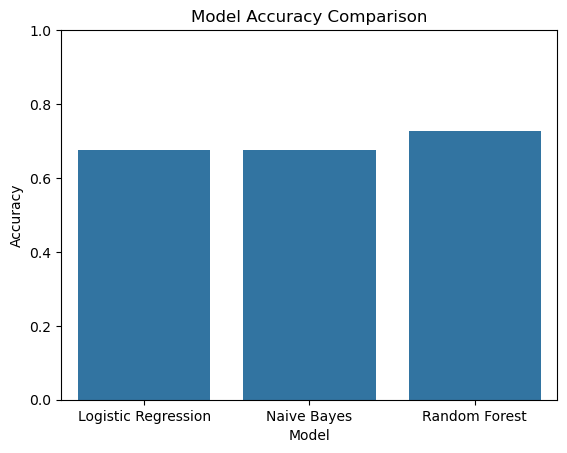

In [60]:
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest']
accuracies = [
    accuracy_score(y_test, log_preds),
    accuracy_score(y_test, nb_preds),
    accuracy_score(y_test, rf_preds)
]

df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

sns.barplot(data=df, x='Model', y='Accuracy')
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

It shows accuracy of each model: Logistic Regression, Naive Bayes, Random Forest

Random Forest has the highest accuracy (72.7%)
Logistic Regression & Naive Bayes are tied at ≈ 67.5%
This helps compare models visually and pick the best performing model.

# Step 19: Save the best Trained Model and Scaler

- We use `joblib` to serialize (save) the trained Random Forest model and the StandardScaler instance to disk.  
- Saving the model (`random_forest_diabetes_model.pkl`) allows us to reuse it later without retraining.  
- Saving the scaler (`scaler.pkl`) ensures that incoming data can be transformed consistently before making predictions with the saved model.

In [73]:
joblib.dump(rf_model, "random_forest_diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [64]:
# ============================
# Define parameter grid
# ============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# ============================
# Initialize Random Forest
# ============================
rf = RandomForestClassifier(random_state=42)

# ============================
# Grid Search on scaled & resampled data
# ============================
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on SMOTE-resampled and scaled training data
grid_search.fit(X_train_scaled, y_train_resampled)

# ============================
# Best hyperparameters
# ============================
print("Best Parameters:", grid_search.best_params_)

# ============================
# Use best estimator
# ============================
best_rf = grid_search.best_estimator_

# ============================
# Predict on scaled test data
# ============================
y_pred_best = best_rf.predict(X_test_scaled)

# ============================
# Evaluate model
# ============================
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest Accuracy: 0.7272727272727273
Confusion Matrix:
 [[77 23]
 [19 35]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [69]:
# Initialize JavaScript visualization library
shap.initjs()

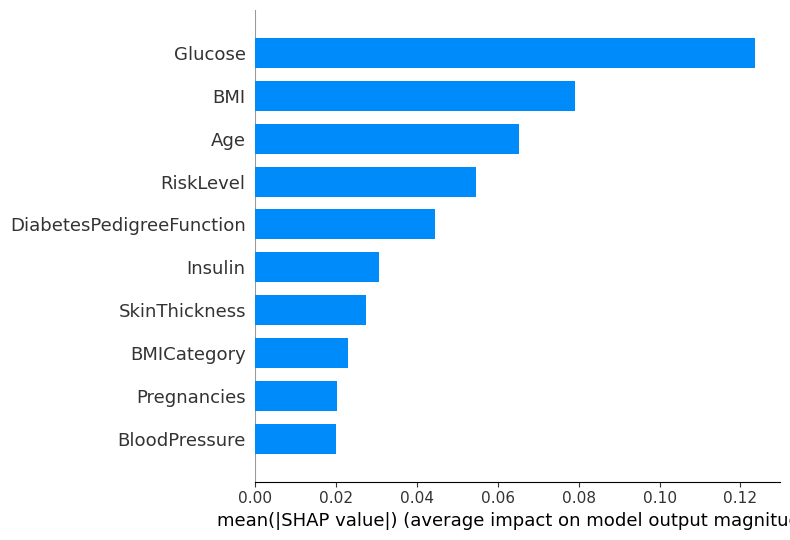

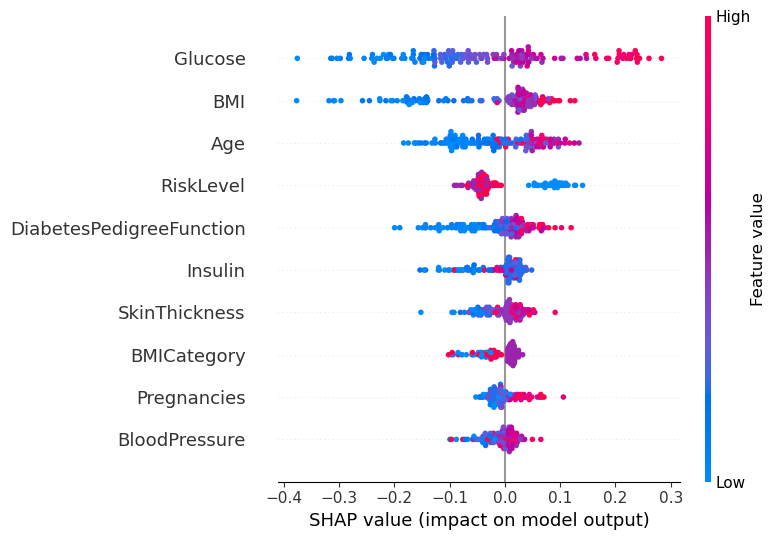

In [70]:
# Convert scaled test set to DataFrame with feature names
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Create SHAP explainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_df)

# Summary plot (bar plot for feature importance)
shap.summary_plot(shap_values[1], X_test_df, plot_type="bar")

# Detailed summary plot (dot plot showing impact of feature values)
shap.summary_plot(shap_values[1], X_test_df)

In [71]:
# Select a single sample from the scaled test set
sample = X_test_df.iloc[0]

# Generate SHAP force plot
shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0],
    sample
)

In [74]:
# Save the tuned Random Forest and scaler
joblib.dump(best_rf, "random_forest_tuned.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']